In [8]:
from pathlib import Path

from huggingface_hub import snapshot_download
from transformers import AutoModel, AutoTokenizer

MODEL_ID = "freedomking/mc-bert"
WORKSPACE_DIR = Path(".").resolve()
LOCAL_MODEL_DIR = WORKSPACE_DIR / "models" / "mc-bert"
LOCAL_CACHE_DIR = WORKSPACE_DIR / ".hf-cache"

LOCAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def has_local_model(model_dir: Path) -> bool:
    has_config = (model_dir / "config.json").exists()
    has_vocab = (model_dir / "vocab.txt").exists()
    has_weights = (model_dir / "pytorch_model.bin").exists() or (model_dir / "model.safetensors").exists()
    return has_config and has_vocab and has_weights


if not has_local_model(LOCAL_MODEL_DIR):
    try:
        snapshot_download(
            repo_id=MODEL_ID,
            local_dir=str(LOCAL_MODEL_DIR),
            cache_dir=str(LOCAL_CACHE_DIR),
            local_dir_use_symlinks=False,
            resume_download=True,
        )
    except Exception as exc:
        raise RuntimeError(
            f"首次下载失败，请检查网络/代理，或手动把模型文件放到: {LOCAL_MODEL_DIR}"
        ) from exc

# Enforce loading from workspace-local model directory only.
tokenizer = AutoTokenizer.from_pretrained(str(LOCAL_MODEL_DIR), local_files_only=True)
model = AutoModel.from_pretrained(str(LOCAL_MODEL_DIR), torch_dtype="auto", local_files_only=True)

print(f"Model dir: {LOCAL_MODEL_DIR}")
print(f"Cache dir (workspace-local): {LOCAL_CACHE_DIR}")

Model dir: /home/projects/AI-Inquiry/models/mc-bert
Cache dir (workspace-local): /home/projects/AI-Inquiry/.hf-cache


In [9]:
import pandas as pd


def read_csv_with_fallback(path, encodings=("utf-8-sig", "utf-8", "gb18030", "gbk")):
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError as exc:
            last_error = exc
    raise last_error


train_path = "dataset/triage/label_1_cls_data/label_1_train.csv"
test_path = "dataset/triage/label_1_cls_data/label_1_test.csv"

train_data = read_csv_with_fallback(train_path)
test_data = read_csv_with_fallback(test_path)

print(train_data.head())
print(test_data.head())

                 titles                                              infos  \
0  早上刚醒左边门牙痛的厉害一点右边有一点痛                     早上刚醒左边门牙痛的厉害一点右边有一点痛我想问一下是什么原因   
1           精神崩溃时人有哪些表现                  精神崩溃时人有哪些表现精神崩溃时人有哪些表现精神崩溃时人有哪些表现   
2     来完月经肚子疼腰疼，2月份药流清宫  来完月经肚子疼腰疼，2月份药流清宫，复查过流的干净，但是这个月月经走后就肚子不舒服，前俩年得...   
3       喉咙抖了几下。就是抽筋的感觉。  刚才窝着坐在沙发上的时候喉咙突然抖了一两秒钟，不痛不痒的，就是有点吓到了，而且我一直喉咙有异...   
4      白带发黄，腥臭味儿，瘙痒。。。。            月经前后会有腥臭味儿，现在月经快完了腥臭味儿又有了。是什么炎症吗，白带发黄瘙痒   

  labels_1_word  labels_1  
0           五官科        11  
1         心理健康科         3  
2           妇产科         5  
3           五官科        11  
4           妇产科         5  
                 titles                                              infos  \
0  用什么药可去除泪管瘤，激光据说会留疤。有                  不疼不痒，影响美观，。是不是治疗皮肤癌的药可以退去呢？有点不敢用。   
1          泌乳素高.去挂什么科rt          wt泌乳素高，不知道去医院挂什么科，拍了脑部磁共振，乳房有粘的分泌物.GYKZBZ   
2  宝宝半个月了，因为上火睡觉总是惊醒必须抱  宝宝半个月了，因为上火睡觉总是惊醒必须抱着才能继续入睡，但是一直抱着对他的身体发宵会有影响吗...   
3      宝宝脖子歪向右侧，脖子处无硬块。                4个月大的婴儿，竖抱时头

In [10]:
import json
import numpy as np

LABEL_COL = "labels_1"
INFO_COL = "infos"
TEXT_COL = "text"
LABEL_DICT_PATH = "dataset/triage/label_1_cls_data/label_1_dict.json"


def build_text(df):
    return df[INFO_COL].fillna("").astype(str).str.strip()


train_df = train_data.copy()
test_df = test_data.copy()
train_df[TEXT_COL] = build_text(train_df)
test_df[TEXT_COL] = build_text(test_df)

raw_label_values = sorted(set(train_df[LABEL_COL].astype(int).tolist()) | set(test_df[LABEL_COL].astype(int).tolist()))
raw_to_idx = {raw: idx for idx, raw in enumerate(raw_label_values)}
idx_to_raw = {idx: raw for raw, idx in raw_to_idx.items()}

with open(LABEL_DICT_PATH, "r", encoding="utf-8") as f:
    dept_to_raw = json.load(f)
raw_to_dept = {int(v): str(k) for k, v in dept_to_raw.items()}

train_df["label"] = train_df[LABEL_COL].astype(int).map(raw_to_idx)
test_df["label"] = test_df[LABEL_COL].astype(int).map(raw_to_idx)

num_labels = len(raw_label_values)
id2label = {
    idx: raw_to_dept.get(idx_to_raw[idx], f"label_{idx_to_raw[idx]}")
    for idx in range(num_labels)
}
label2id = {name: idx for idx, name in id2label.items()}

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")
print(f"Num labels: {num_labels}")
print("Label mapping (raw -> model_idx):", raw_to_idx)
print("Model idx to department:", id2label)

Train size: 373686 | Test size: 65944
Num labels: 14
Label mapping (raw -> model_idx): {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13}
Model idx to department: {0: '肿瘤科', 1: '整形美容科', 2: '康复医学科', 3: '心理健康科', 4: '儿科', 5: '妇产科', 6: '传染科', 7: '皮肤性病科', 8: '辅助检查科', 9: '内科', 10: '外科', 11: '五官科', 12: '营养保健科', 13: '中医科'}


In [11]:
from datasets import Dataset

MAX_LENGTH = 128

train_ds = Dataset.from_pandas(train_df[[TEXT_COL, "label"]], preserve_index=False)
test_ds = Dataset.from_pandas(test_df[[TEXT_COL, "label"]], preserve_index=False)


def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        max_length=MAX_LENGTH,
    )


train_ds = train_ds.map(tokenize_batch, batched=True, remove_columns=[TEXT_COL])
test_ds = test_ds.map(tokenize_batch, batched=True, remove_columns=[TEXT_COL])

print(train_ds)
print(test_ds)
print("Example tokenized length:", len(train_ds[0]["input_ids"]))

Map: 100%|██████████| 65944/65944 [00:04<00:00, 14850.22 examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 373686
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 65944
})
Example tokenized length: 32


In [12]:
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

OUTPUT_DIR = WORKSPACE_DIR / "outputs" / "mc-bert-label1"
FINETUNED_DIR = WORKSPACE_DIR / "models" / "mc-bert-triage-label1"

classifier_model = AutoModelForSequenceClassification.from_pretrained(
    str(LOCAL_MODEL_DIR),
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    local_files_only=True,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }


training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    overwrite_output_dir=True,
    learning_rate=5e-5,
    per_device_train_batch_size=512,
    per_device_eval_batch_size=256,
    num_train_epochs=20,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=classifier_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Trainer ready. Start training in next cell.")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /home/projects/AI-Inquiry/models/mc-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainer ready. Start training in next cell.


/tmp/ipykernel_11290/1147362929.py:59: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.622500,0.597863,0.805577,0.640561,0.594413,0.612927
2,0.552100,0.569803,0.811613,0.656444,0.611001,0.623509
3,0.500500,0.561373,0.814570,0.648025,0.630266,0.633791
4,0.457900,0.579055,0.813872,0.643574,0.624917,0.631972
5,0.381200,0.607324,0.812705,0.638181,0.623618,0.628582
6,0.339200,0.637797,0.809217,0.702725,0.629672,0.640286


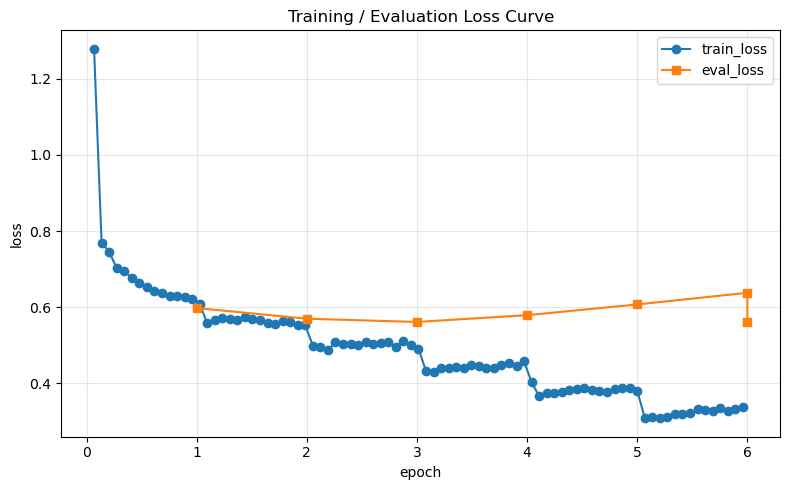

Loss curve saved to: /home/projects/AI-Inquiry/outputs/mc-bert-label1/loss_curve.png
Train result: TrainOutput(global_step=4380, training_loss=0.4871019513639685, metrics={'train_runtime': 1596.9296, 'train_samples_per_second': 4680.056, 'train_steps_per_second': 9.143, 'total_flos': 1.474972668591575e+17, 'train_loss': 0.4871019513639685, 'epoch': 6.0})
Eval metrics: {'eval_loss': 0.561373233795166, 'eval_accuracy': 0.8145699381293219, 'eval_macro_precision': 0.6480250986451458, 'eval_macro_recall': 0.6302664827262798, 'eval_macro_f1': 0.6337908800615036, 'eval_runtime': 18.0344, 'eval_samples_per_second': 3656.569, 'eval_steps_per_second': 14.306, 'epoch': 6.0}
Log history saved to: /home/projects/AI-Inquiry/outputs/mc-bert-label1/trainer_log_history.csv
Fine-tuned model saved to: /home/projects/AI-Inquiry/models/mc-bert-triage-label1


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_result = trainer.train()
eval_metrics = trainer.evaluate()

FINETUNED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(FINETUNED_DIR))
tokenizer.save_pretrained(str(FINETUNED_DIR))

# Save raw trainer logs for reproducibility/inspection.
log_history = trainer.state.log_history
log_df = pd.DataFrame(log_history)
log_csv_path = OUTPUT_DIR / "trainer_log_history.csv"
log_df.to_csv(log_csv_path, index=False, encoding="utf-8-sig")

train_loss_df = pd.DataFrame()
eval_loss_df = pd.DataFrame()

if "loss" in log_df.columns:
    train_loss_df = log_df[log_df["loss"].notna()].copy()
if "eval_loss" in log_df.columns:
    eval_loss_df = log_df[log_df["eval_loss"].notna()].copy()

if not train_loss_df.empty or not eval_loss_df.empty:
    plt.figure(figsize=(8, 5))

    if not train_loss_df.empty:
        x_train = train_loss_df["epoch"] if "epoch" in train_loss_df.columns else np.arange(1, len(train_loss_df) + 1)
        plt.plot(x_train, train_loss_df["loss"], marker="o", linewidth=1.5, label="train_loss")

    if not eval_loss_df.empty:
        x_eval = eval_loss_df["epoch"] if "epoch" in eval_loss_df.columns else np.arange(1, len(eval_loss_df) + 1)
        plt.plot(x_eval, eval_loss_df["eval_loss"], marker="s", linewidth=1.5, label="eval_loss")

    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training / Evaluation Loss Curve")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    loss_curve_path = OUTPUT_DIR / "loss_curve.png"
    plt.savefig(loss_curve_path, dpi=200)
    plt.show()
    print(f"Loss curve saved to: {loss_curve_path}")
else:
    print("No loss records found in trainer.state.log_history.")

print("Train result:", train_result)
print("Eval metrics:", eval_metrics)
print(f"Log history saved to: {log_csv_path}")
print(f"Fine-tuned model saved to: {FINETUNED_DIR}")

In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

if (FINETUNED_DIR / "config.json").exists():
    inference_model = AutoModelForSequenceClassification.from_pretrained(
        str(FINETUNED_DIR),
        local_files_only=True,
    )
    print(f"Using fine-tuned model: {FINETUNED_DIR}")
else:
    inference_model = classifier_model
    print("Fine-tuned model not found yet, using current in-memory model for sanity check.")

inference_model.eval()


def predict_department(text: str):
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    with torch.no_grad():
        logits = inference_model(**encoded).logits
        probs = torch.softmax(logits, dim=-1)
        pred_idx = int(torch.argmax(probs, dim=-1).item())
        pred_score = float(probs[0, pred_idx].item())
    return {
        "pred_idx": pred_idx,
        "pred_department": id2label[pred_idx],
        "confidence": round(pred_score, 4),
    }


sample_text = "我眼睛太小了"
print(predict_department(sample_text))

Using fine-tuned model: /home/projects/AI-Inquiry/models/mc-bert-triage-label1
{'pred_idx': 11, 'pred_department': '五官科', 'confidence': 0.9747}
